In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam
from keras.optimizers import Adam

In [5]:
data = pd.read_csv(r"D:\ANN and DL\GestureDataset_110x110x3.csv", header=None)
Y = data.iloc[:, 0].values
X = data.iloc[:, 1:].values
X = X.astype('float32') / 255.0

encoder = LabelEncoder()
Y = encoder.fit_transform(Y)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Xtrain = Xtrain.reshape((Xtrain.shape[0], 110, 110, 3))
Xtest = Xtest.reshape((Xtest.shape[0], 110, 110, 3))

num_classes = len(np.unique(Y))
Ytrain = to_categorical(Ytrain, num_classes)
Ytest = to_categorical(Ytest, num_classes)

In [6]:
cnn = Sequential()
cnn.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(110,110,3)))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D((2,2)))
cnn.add(Dropout(0.25))

cnn.add(Conv2D(64, (3,3), activation='relu', padding='same'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D((2,2)))
cnn.add(Dropout(0.25))

cnn.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D((2,2)))
cnn.add(Dropout(0.4))

cnn.add(Flatten())
cnn.add(Dense(256, activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(num_classes, activation='softmax'))

c:\Python\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
optimizer = Adam(learning_rate=0.001)
cnn.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

summary = cnn.fit(Xtrain, Ytrain, validation_data=(Xtest, Ytest), epochs=20, batch_size=64, verbose=1)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.3871 - loss: 3.0671 - val_accuracy: 0.3333 - val_loss: 2.9468
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.4492 - loss: 1.0253 - val_accuracy: 0.3333 - val_loss: 5.7900
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.4929 - loss: 0.9638 - val_accuracy: 0.3333 - val_loss: 9.5543
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.5462 - loss: 0.9019 - val_accuracy: 0.3333 - val_loss: 13.6466
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.5529 - loss: 0.8821 - val_accuracy: 0.3333 - val_loss: 16.3984
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.6062 - loss: 0.7948 - val_accuracy: 0.3333 - val_loss: 20.0062
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6479 - loss: 0.7078 - val_accuracy: 0.3333 - val_loss: 24.3396
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6921 - loss: 0.6402 - val_accuracy: 0.3333 - val_l

Training Accuracy = [0.3870833218097687, 0.4491666555404663, 0.49291667342185974, 0.5462499856948853, 0.5529166460037231, 0.606249988079071, 0.6479166746139526, 0.6920833587646484, 0.7250000238418579, 0.7583333253860474, 0.762499988079071, 0.7766666412353516, 0.8100000023841858, 0.8412500023841858, 0.8691666722297668, 0.8912500143051147, 0.9024999737739563, 0.8895833492279053, 0.925000011920929, 0.9416666626930237]
Testing Accuracy = [0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3566666543483734, 0.3383333384990692, 0.3333333432674408, 0.3333333432674408, 0.35499998927116394, 0.3683333396911621, 0.44333332777023315, 0.3333333432674408]
Training Loss = [3.0671019554138184, 1.0253260135650635, 0.9638487696647644, 0.9018515944480896, 0.8820652365684509, 0.7947573065757751, 0.7077884674072266, 0.

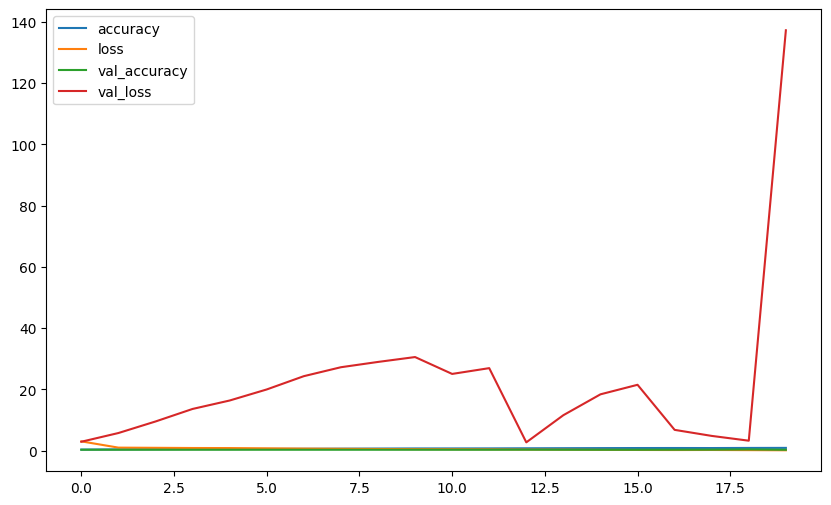

In [10]:
print("Training Accuracy =", summary.history['accuracy'])
print("Testing Accuracy =", summary.history['val_accuracy'])
print("Training Loss =", summary.history['loss'])
print("Testing Loss =", summary.history['val_loss'])

pd.DataFrame(summary.history).plot(figsize=(10,6))
plt.show()